In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\sreya\Downloads\Air_Quality.csv")
df.head()

,id,country,state,city,station,pollutant_id,last_update,pollutant_min,pollutant_max,pollutant_avg
0,1,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM2.5,21-10-2021 01:00:00,69.0,109.0,86.0
1,2,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM10,21-10-2021 01:00:00,82.0,138.0,105.0
2,3,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NO2,21-10-2021 01:00:00,10.0,42.0,19.0
3,4,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NH3,21-10-2021 01:00:00,4.0,5.0,4.0
4,5,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",SO2,21-10-2021 01:00:00,16.0,42.0,27.0


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1836 entries, 0 to 1835
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1836 non-null   int64  
 1   country        1836 non-null   object 
 2   state          1836 non-null   object 
 3   city           1836 non-null   object 
 4   station        1836 non-null   object 
 5   pollutant_id   1836 non-null   object 
 6   last_update    1836 non-null   object 
 7   pollutant_min  1738 non-null   float64
 8   pollutant_max  1738 non-null   float64
 9   pollutant_avg  1738 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 143.6+ KB
None
                id  pollutant_min  pollutant_max  pollutant_avg
count  1836.000000    1738.000000    1738.000000    1738.000000
mean    918.500000      28.414269      96.873418      54.100690
std     530.151865      34.403811     104.765094      60.824158
min       1.000000       1.000000       

In [4]:
# convert date column properly
df['last_update'] = pd.to_datetime(df['last_update'], dayfirst=True, errors='coerce')

# remove missing values
df = df.dropna()

# create month column
df['month'] = df['last_update'].dt.month

In [5]:
# check available columns
print(df.columns)

# try to create pollutant_avg based on what exists
if 'AQI' in df.columns:
    df['pollutant_avg'] = df['AQI']

elif 'pm2.5' in df.columns and 'pm10' in df.columns:
    df['pollutant_avg'] = df[['pm2.5', 'pm10']].mean(axis=1)

elif 'pm2_5' in df.columns and 'pm10' in df.columns:
    df['pollutant_avg'] = df[['pm2_5', 'pm10']].mean(axis=1)

else:
    print("Check dataset columns, pollutant values not found")

df.head()

Index(['id', 'country', 'state', 'city', 'station', 'pollutant_id',
       'last_update', 'pollutant_min', 'pollutant_max', 'pollutant_avg',
       'month'],
      dtype='object')
Check dataset columns, pollutant values not found


,id,country,state,city,station,pollutant_id,last_update,pollutant_min,pollutant_max,pollutant_avg,month
0,1,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM2.5,2021-10-21 01:00:00,69.0,109.0,86.0,10
1,2,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM10,2021-10-21 01:00:00,82.0,138.0,105.0,10
2,3,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NO2,2021-10-21 01:00:00,10.0,42.0,19.0,10
3,4,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NH3,2021-10-21 01:00:00,4.0,5.0,4.0,10
4,5,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",SO2,2021-10-21 01:00:00,16.0,42.0,27.0,10


In [6]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Poor"
    else:
        return "Very Poor"

df['AQI_Category'] = df['pollutant_avg'].apply(categorize_aqi)

df.head()

,id,country,state,city,station,pollutant_id,last_update,pollutant_min,pollutant_max,pollutant_avg,month,AQI_Category
0,1,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM2.5,2021-10-21 01:00:00,69.0,109.0,86.0,10,Moderate
1,2,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",PM10,2021-10-21 01:00:00,82.0,138.0,105.0,10,Poor
2,3,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NO2,2021-10-21 01:00:00,10.0,42.0,19.0,10,Good
3,4,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",NH3,2021-10-21 01:00:00,4.0,5.0,4.0,10,Good
4,5,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",SO2,2021-10-21 01:00:00,16.0,42.0,27.0,10,Good


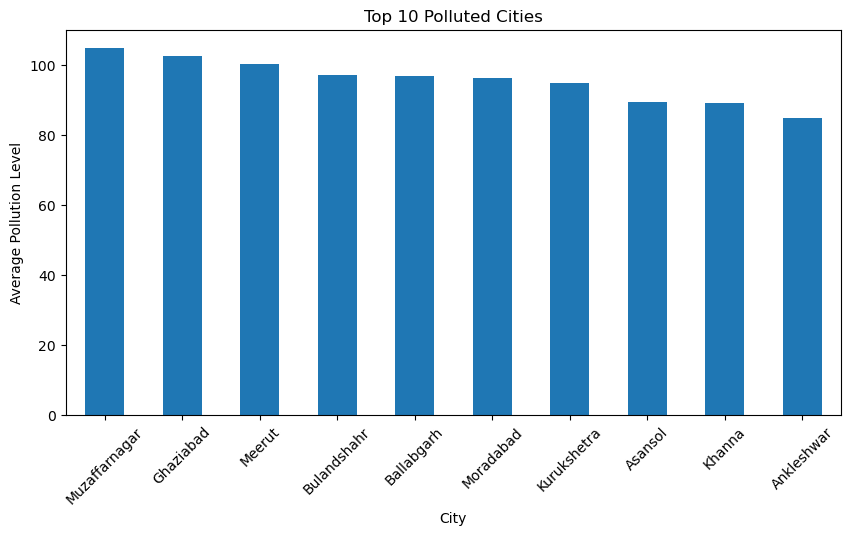

In [7]:
top_cities = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top 10 Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average Pollution Level")
plt.xticks(rotation=45)
plt.show()

In [8]:
print(df[['pollutant_avg']].head())

   pollutant_avg
0           86.0
1          105.0
2           19.0
3            4.0
4           27.0


In [9]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Poor"
    else:
        return "Very Poor"

df['AQI_Category'] = df['pollutant_avg'].apply(categorize_aqi)

df[['pollutant_avg', 'AQI_Category']].head()

,pollutant_avg,AQI_Category
0,86.0,Moderate
1,105.0,Poor
2,19.0,Good
3,4.0,Good
4,27.0,Good


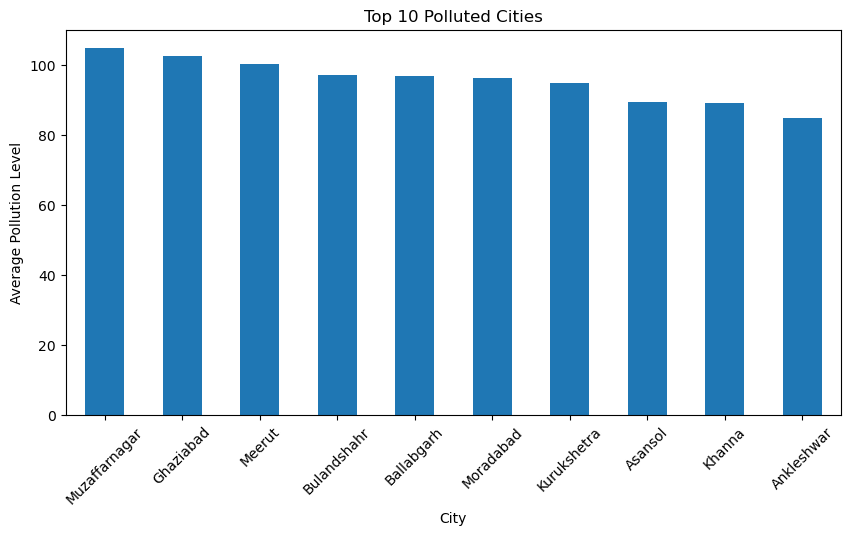

In [10]:
top_cities = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top 10 Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average Pollution Level")
plt.xticks(rotation=45)
plt.show()

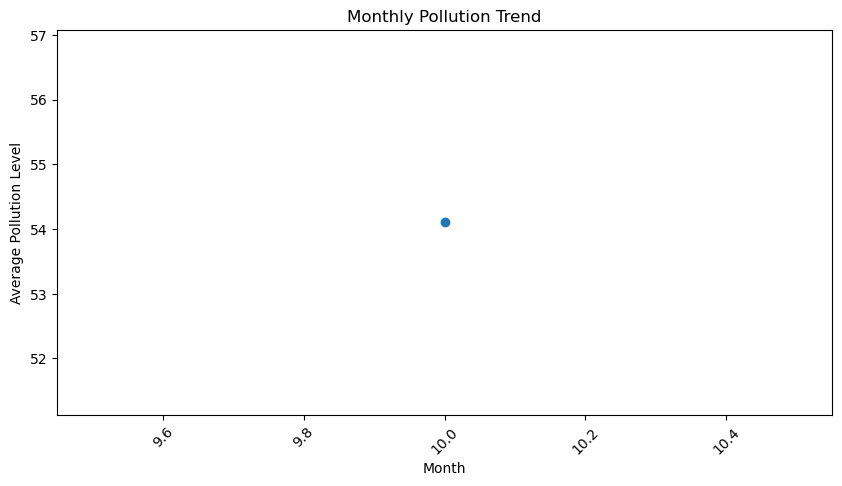

In [11]:
monthly_trend = df.groupby('month')['pollutant_avg'].mean()

plt.figure(figsize=(10,5))
monthly_trend.plot(marker='o')
plt.title("Monthly Pollution Trend")
plt.xlabel("Month")
plt.ylabel("Average Pollution Level")
plt.xticks(rotation=45)
plt.show()

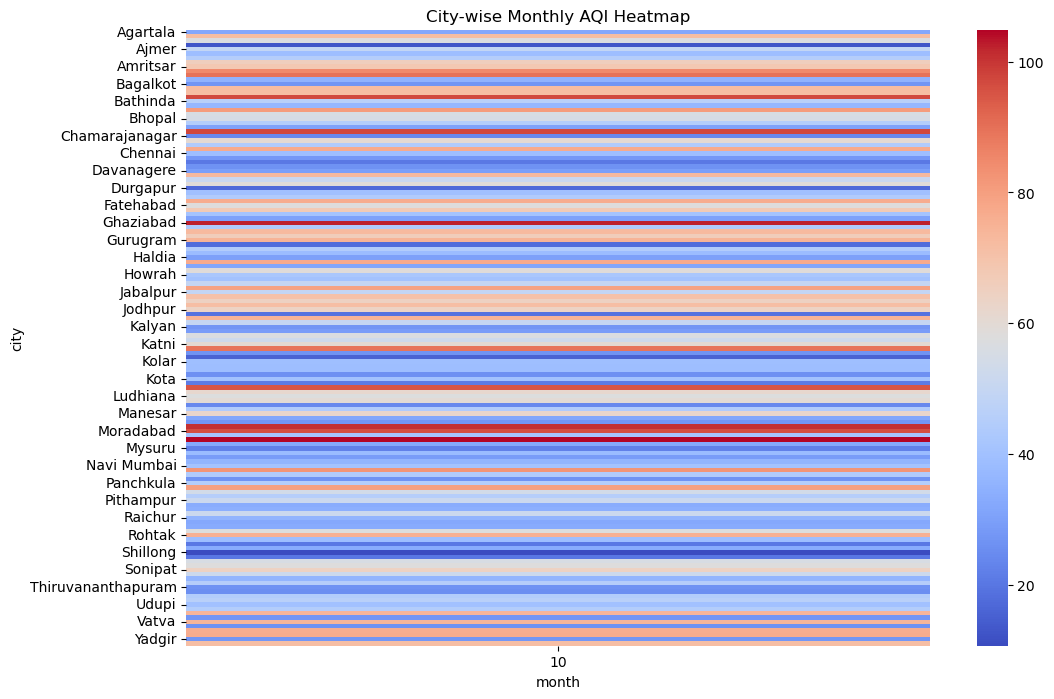

In [12]:
heatmap_data = df.pivot_table(index='city', columns='month', values='pollutant_avg', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap='coolwarm')
plt.title("City-wise Monthly AQI Heatmap")
plt.show()

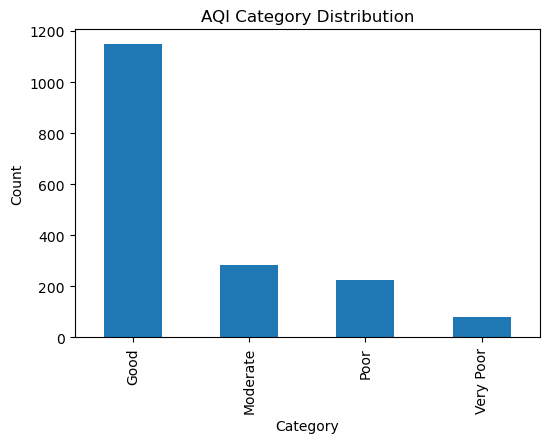

In [13]:
category_count = df['AQI_Category'].value_counts()

plt.figure(figsize=(6,4))
category_count.plot(kind='bar')
plt.title("AQI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [14]:
def health_advice(category):
    if category == "Good":
        return "Air is clean. Safe for outdoor activities."
    elif category == "Moderate":
        return "Acceptable air quality. Sensitive people take care."
    elif category == "Poor":
        return "Wear mask. Avoid long outdoor exposure."
    else:
        return "Stay indoors. Health risk for everyone."

df['Health_Advice'] = df['AQI_Category'].apply(health_advice)

df[['city', 'AQI_Category', 'Health_Advice']].head()

,city,AQI_Category,Health_Advice
0,Amaravati,Moderate,Acceptable air quality. Sensitive people take ...
1,Amaravati,Poor,Wear mask. Avoid long outdoor exposure.
2,Amaravati,Good,Air is clean. Safe for outdoor activities.
3,Amaravati,Good,Air is clean. Safe for outdoor activities.
4,Amaravati,Good,Air is clean. Safe for outdoor activities.


In [2]:
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Title
display(HTML("<h1 style='color:green;'>🌍 Air Quality Dashboard</h1>"))

# Layout containers
left_box = widgets.VBox()
right_box = widgets.VBox()
main_box = widgets.HBox([left_box, right_box])

# Input
city_dropdown = widgets.Dropdown(
    options=sorted(df['city'].unique()),
    description='City:',
    style={'description_width': 'initial'}
)

button = widgets.Button(
    description="Check AQI",
    button_style='success'
)

# Output areas
result_output = widgets.Output()
graph_output = widgets.Output()

def on_button_click(b):
    with result_output:
        result_output.clear_output()
        
        city = city_dropdown.value
        city_data = df[df['city'] == city]

        avg_aqi = city_data['pollutant_avg'].mean()
        category = categorize_aqi(avg_aqi)
        advice = health_advice(category)

        # color logic
        if category == "Good":
            color = "green"
        elif category == "Moderate":
            color = "orange"
        else:
            color = "red"

        display(HTML(f"""
        <h2>AQI: {round(avg_aqi,2)}</h2>
        <h3 style='color:{color};'>Category: {category}</h3>
        <p><b>Advice:</b> {advice}</p>
        """))

    with graph_output:
        graph_output.clear_output()
        
        monthly = city_data.groupby('month')['pollutant_avg'].mean()

        plt.figure()
        monthly.plot(marker='o')
        plt.title(f"Monthly Trend for {city}")
        plt.xlabel("Month")
        plt.ylabel("AQI")
        plt.show()

button.on_click(on_button_click)

# Arrange layout
left_box.children = [city_dropdown, button]
right_box.children = [result_output]

display(main_box)
display(graph_output)

NameError: name 'df' is not defined